In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Đường dẫn đến file trọng số mô hình đã huấn luyện sẵn
pretrained_model = "models/lenet_mnist_model.pth"


In [6]:
#ĐỊNH NGHĨA MÔ HÌNH LeNet

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

# TẢI DỮ LIỆU KIỂM TRA MNIST
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('dataset', train=False, download=True,
                   transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            ])),
        batch_size=1, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device} ")

model = Net().to(device)

model.load_state_dict(torch.load(pretrained_model, map_location=device, weights_only=True))
model.eval()

Đang sử dụng thiết bị: cpu 


Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [10]:
# HÀM KHÔI PHỤC ẢNH
def denorm(batch, mean=[0.1307], std=[0.3081]):
    """
    Khôi phục batch tensor về thang giá trị gốc (trước khi chuẩn hóa).

    Tham số:
        batch (torch.Tensor): Batch tensor đã được chuẩn hóa
        mean, std : Giá trị trung bình và độ lệch chuẩn đã dùng để chuẩn hóa
    Trả về:
        torch.Tensor: Tensor ở thang gốc

    Công thức: x_goc = x_norm * std + mean
    """
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)


---
## Demo Trước Tấn Công

Lấy **8 ảnh ngẫu nhiên** từ tập test MNIST, cho qua mô hình và hiển thị kết quả nhận diện.

Ở bước này mô hình đang hoạt động **bình thường**, chưa có bất kỳ nhiễu nào.

---


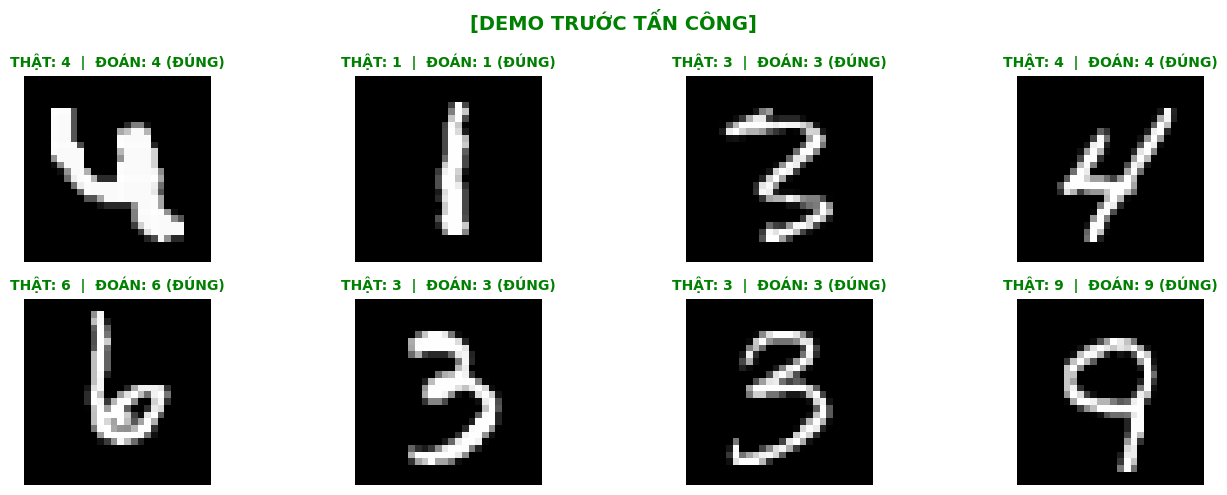

=> Mô hình nhận đúng 8/8 ảnh trước khi bị tấn công.


In [11]:
# DEMO TRƯỚC TẤN CÔNG

NUM_DEMO = 8
demo_data = []   # lưu thông tin ảnh demo

model.eval()
for data, target in test_loader:
    if len(demo_data) >= NUM_DEMO:
        break
    data, target = data.to(device), target.to(device)

    output = model(data)
    pred = output.max(1, keepdim=True)[1]

    #Khôi phục ảnh đã được chuẩn hóa, để hiển thị
    orig_np = denorm(data).squeeze().detach().cpu().numpy()
    # lưu (ảnh gốc, tensor ảnh, nhãn thật, dự đoán)
    demo_data.append((orig_np, data.detach().clone(), target.item(), pred.item()))

# Vẽ demo TRƯỚC tấn công
fig, axes = plt.subplots(2, NUM_DEMO // 2, figsize=(14, 5))
axes = axes.flatten()
fig.suptitle('[DEMO TRƯỚC TẤN CÔNG]', fontsize=14, fontweight='bold', color='green')

cnt=0
for i, (img_np, _, true_lbl, pred_lbl) in enumerate(demo_data):
    axes[i].imshow(img_np, cmap='gray')
    if pred_lbl == true_lbl:
        axes[i].set_title(f'THẬT: {true_lbl}  |  ĐOÁN: {pred_lbl} (ĐÚNG)',fontweight='bold', fontsize=10, color='green')
        cnt+=1
    else:
        axes[i].set_title(f'THẬT: {true_lbl}  |  ĐOÁN: {pred_lbl} (SAI)',fontweight='bold', fontsize=10, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print(f"=> Mô hình nhận đúng {cnt}/{NUM_DEMO} ảnh trước khi bị tấn công.")


---
##  Tấn Công Bằng Nhiễu FGSM

Dùng gradient đã tính ở bước trên, tạo nhiễu FGSM với `epsilon = {demo_epsilon}` và cộng vào từng ảnh.

Nhìn bằng mắt thường ảnh **trông gần như không đổi**, nhưng bên trong đã bị thay đổi từng pixel theo hướng tối đa hoá lỗi của mô hình.

---


In [ ]:
# HÀM TẤN CÔNG FGSM
def fgsm_attack(image, epsilon, data_grad):
    # Bước 1: Lấy dấu của gradient theo từng pixel
    sign_data_grad = data_grad.sign()
    # Bước 2: Cộng nhiễu vào ảnh theo hướng làm tăng loss tối đa
    perturbed_image = image + epsilon * sign_data_grad
    # Bước 3: Giữ giá trị pixel trong khoảng [0,1]
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

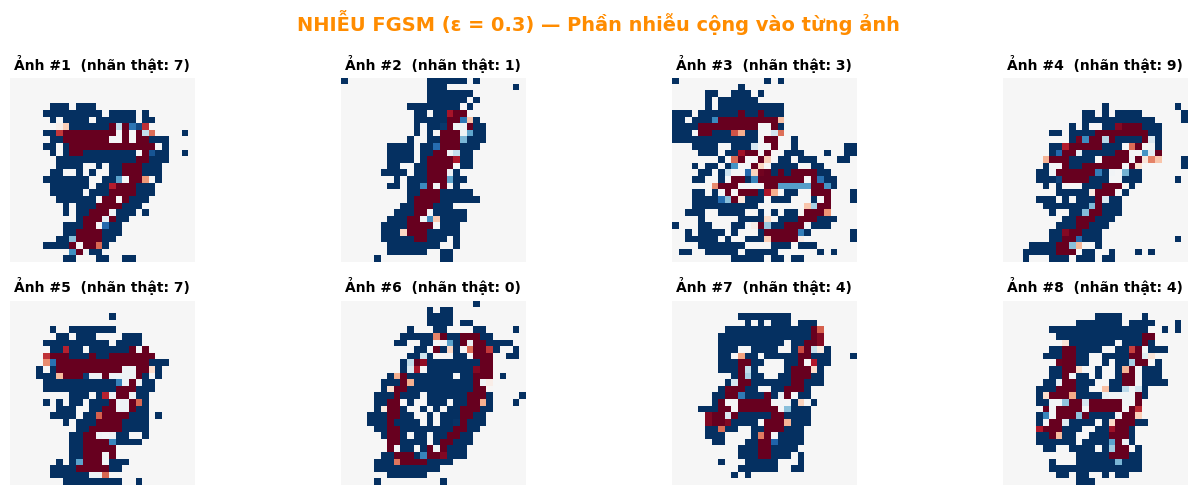

=> Đã tạo nhiễu FGSM (ε = 0.3) cho 8 ảnh


In [7]:
# TẠO NHIỄU FGSM VÀ HIỂN THỊ NHIỄU
demo_epsilon = 0.3  # Mức độ nhiễu
attacked_data = []
for (orig_np, data_tensor, true_lbl, pred_before) in demo_data:
    # Tính gradient
    data_tensor = data_tensor.to(device)
    data_tensor.requires_grad = True
    target_tensor = torch.tensor([true_lbl]).to(device)
    out = model(data_tensor)
    loss = F.nll_loss(out, target_tensor)
    model.zero_grad()
    loss.backward()
    data_grad = data_tensor.grad.data  # gradient để tạo nhiễu FGSM

    # Khôi phục ảnh về [0,1] rồi thêm nhiễu FGSM
    data_denorm = denorm(data_tensor) # ảnh gốc
    perturbed   = fgsm_attack(data_denorm, demo_epsilon, data_grad) # ảnh đã bị nhiễu
    noise       = perturbed - data_denorm   # Phần nhiễu được thêm vào

    # Dự đoán lại ảnh đã nhiễu
    perturbed_norm = transforms.Normalize((0.1307,), (0.3081,))(perturbed)
    with torch.no_grad():
        out2 = model(perturbed_norm)
    pred_after = out2.max(1, keepdim=True)[1].item()

    # Lưu ảnh bị tấn công (ảnh gốc, nhiễu, ảnh sau tấn công, nhãn thật, dự đoán trước, dự đoán sau)
    attacked_data.append((orig_np,noise.squeeze().detach().cpu().numpy(),
                          perturbed.squeeze().detach().cpu().numpy(),true_lbl,pred_before,pred_after))
# Hiển thị nhiễu FGSM
fig, axes = plt.subplots(2, NUM_DEMO // 2, figsize=(14, 5))
axes = axes.flatten()
fig.suptitle(f'NHIỄU FGSM (ε = {demo_epsilon}) — Phần nhiễu cộng vào từng ảnh',
                    fontsize=14, fontweight='bold', color='darkorange')

for i, (_, noise_np, _, true_lbl, _, _) in enumerate(attacked_data):
    im = axes[i].imshow(noise_np, cmap='RdBu', vmin=-demo_epsilon, vmax=demo_epsilon)
    axes[i].set_title(f'Ảnh #{i+1}  (nhãn thật: {true_lbl})', fontweight='bold', fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()
print(f"=> Đã tạo nhiễu FGSM (ε = {demo_epsilon}) cho {NUM_DEMO} ảnh")


---
##  Demo Sau Tấn Công

Cho ảnh đã bị nhiễu qua mô hình và xem kết quả nhận diện.

Mô hình bây giờ sẽ đọc **sai** — trong khi mắt người vẫn nhận ra đúng chữ số.

---


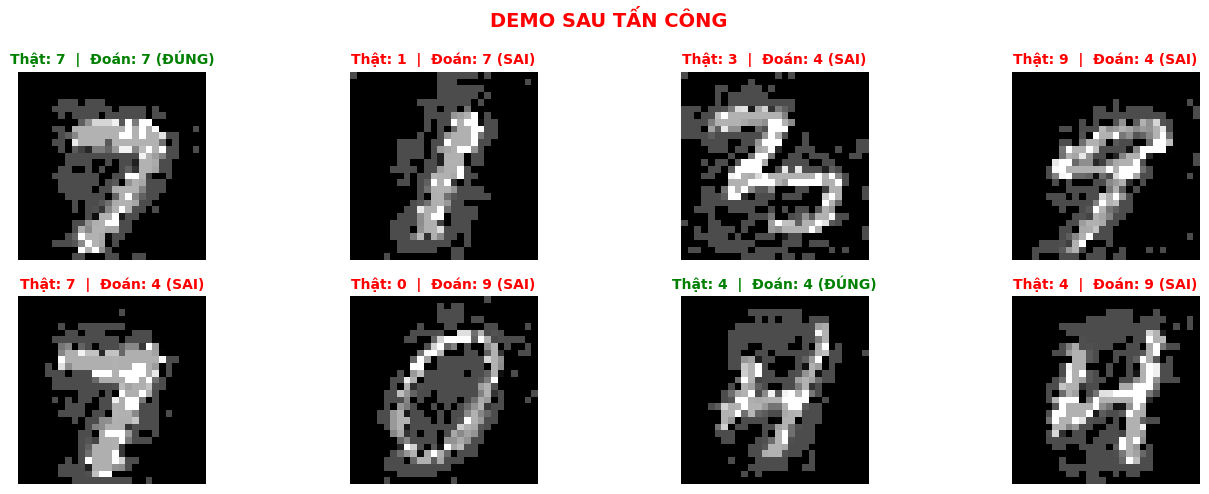

=> Sau tấn công: mô hình bị lừa 6/8 ảnh  (ε = 0.3)


In [8]:
# DEMO SAU TẤN CÔNG

fig, axes = plt.subplots(2, NUM_DEMO // 2, figsize=(14, 5))
axes = axes.flatten()
fig.suptitle('DEMO SAU TẤN CÔNG', fontsize=14, fontweight='bold', color='red')

for i, (_, _, adv_np, true_lbl, pred_before, pred_after) in enumerate(attacked_data):
    axes[i].imshow(adv_np, cmap='gray')
    if pred_after != true_lbl:
        title = f'Thật: {true_lbl}  |  Đoán: {pred_after} (SAI)'
        color = 'red'
    else:
        title = f'Thật: {true_lbl}  |  Đoán: {pred_after} (ĐÚNG)'
        color = 'green'
    axes[i].set_title(title, fontweight='bold', fontsize=10, color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

n_fooled = sum(1 for (_, _, _, tl, _, pa) in attacked_data if pa != tl)
print(f"=> Sau tấn công: mô hình bị lừa {n_fooled}/{NUM_DEMO} ảnh  (ε = {demo_epsilon})")


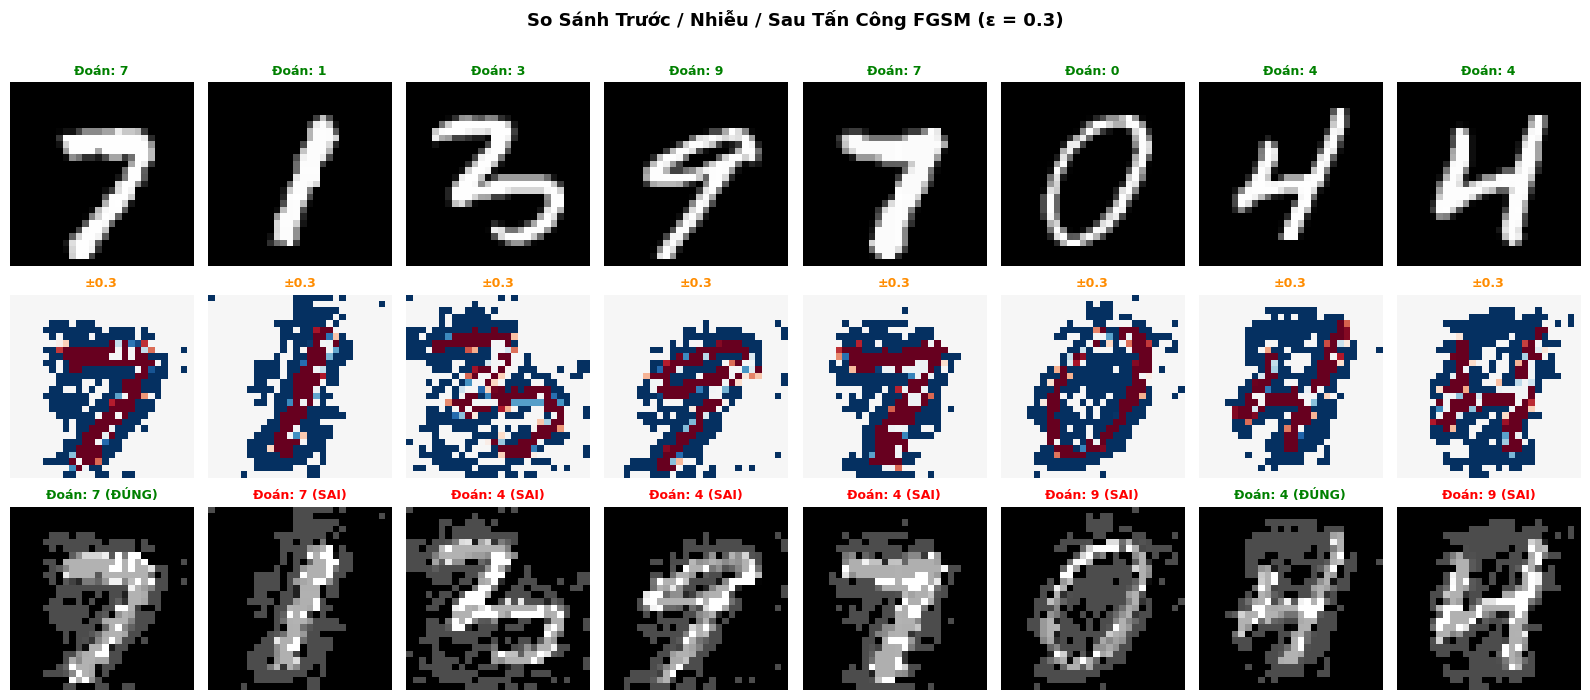

In [9]:
# SO SÁNH KẾT QUẢ TỔNG QUAN TRƯỚC/NHIỄU/SAU TRÊN CÙNG LƯỚI ẢNH

fig, axes = plt.subplots(3, NUM_DEMO, figsize=(16, 7))
row_labels = [
    f'Trước tấn công (ε = 0)',
    f'Nhiễu FGSM (ε = {demo_epsilon})',
    f'Sau tấn công (ε = {demo_epsilon})'
]

for row in range(3):
    axes[row][0].set_ylabel(row_labels[row], fontsize=9, fontweight='bold')

for col, (orig_np, noise_np, adv_np, true_lbl, pred_before, pred_after) in enumerate(attacked_data):
    axes[0][col].imshow(orig_np, cmap='gray')
    axes[0][col].set_title(f'Đoán: {pred_before}', fontsize=9, fontweight='bold', color='green')
    axes[0][col].axis('off')

    axes[1][col].imshow(noise_np, cmap='RdBu', vmin=-demo_epsilon, vmax=demo_epsilon)
    axes[1][col].set_title(f'±{demo_epsilon}', fontsize=9, fontweight='bold', color='darkorange')
    axes[1][col].axis('off')

    axes[2][col].imshow(adv_np, cmap='gray')
    if pred_after != true_lbl:
        axes[2][col].set_title(f'Đoán: {pred_after} (SAI)', fontsize=9, fontweight='bold', color='red')
    else:
        axes[2][col].set_title(f'Đoán: {pred_after} (ĐÚNG)', fontsize=9, fontweight='bold', color='green')
    axes[2][col].axis('off')

plt.suptitle(f'So Sánh Trước / Nhiễu / Sau Tấn Công FGSM (ε = {demo_epsilon})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Đánh Giá Tổng Thể Trên Toàn Bộ Tập Test

Bây giờ chạy tấn công trên **toàn bộ 10,000 ảnh** của tập test với nhiều mức epsilon khác nhau để đo độ chính xác.

---


In [10]:
# KIỂM TRA TOÀN BỘ TẬP TEST
# Danh sách epsilon: từ 0 (không tấn công) đến 0.3 (tấn công mạnh)
epsilons = [0, .05, .1, .15, .2, .25, .3]
def test(model, device, test_loader, epsilon):
    correct = 0
    adv_examples = []

    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        data.requires_grad = True

        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]
        if init_pred.item() != target.item():
            continue

        loss = F.nll_loss(output, target)
        model.zero_grad()
        loss.backward()
        data_grad = data.grad.data

        data_denorm = denorm(data)
        perturbed_data = fgsm_attack(data_denorm, epsilon, data_grad)
        perturbed_data_normalized = transforms.Normalize((0.1307,), (0.3081,))(perturbed_data)

        output = model(perturbed_data_normalized)
        final_pred = output.max(1, keepdim=True)[1]

        if final_pred.item() == target.item():
            correct += 1
            if epsilon == 0 and len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex))
        else:
            if len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex))

    final_acc = correct / float(len(test_loader))
    print(f"  ε = {epsilon:<5}  →  Đúng: {correct:>5} / {len(test_loader)}  →  Độ chính xác: {final_acc*100:.1f}%")
    return final_acc, adv_examples


In [11]:
# CHẠY TẤN CÔNG VỚI TỪNG GIÁ TRỊ EPSILON

print("🚀 Đang chạy tấn công FGSM trên toàn bộ tập test...\n")
accuracies = []
examples   = []

for eps in epsilons:
    acc, ex = test(model, device, test_loader, eps)
    accuracies.append(acc)
    examples.append(ex)

print(f"\n✅ Hoàn thành! Độ chính xác giảm từ {accuracies[0]*100:.1f}% → {accuracies[-1]*100:.1f}%")


🚀 Đang chạy tấn công FGSM trên toàn bộ tập test...

  ε = 0      →  Đúng:  9912 / 10000  →  Độ chính xác: 99.1%
  ε = 0.05   →  Đúng:  9605 / 10000  →  Độ chính xác: 96.0%
  ε = 0.1    →  Đúng:  8743 / 10000  →  Độ chính xác: 87.4%
  ε = 0.15   →  Đúng:  7111 / 10000  →  Độ chính xác: 71.1%
  ε = 0.2    →  Đúng:  4886 / 10000  →  Độ chính xác: 48.9%
  ε = 0.25   →  Đúng:  2724 / 10000  →  Độ chính xác: 27.2%
  ε = 0.3    →  Đúng:  1422 / 10000  →  Độ chính xác: 14.2%

✅ Hoàn thành! Độ chính xác giảm từ 99.1% → 14.2%


---
## Biểu Đồ So Sánh Trực Quan

### Biểu đồ 1: Độ chính xác giảm theo epsilon
### Biểu đồ 2: Tỉ lệ bị lừa tăng theo epsilon
### Biểu đồ 3: Bảng thanh so sánh trước/sau từng epsilon

---


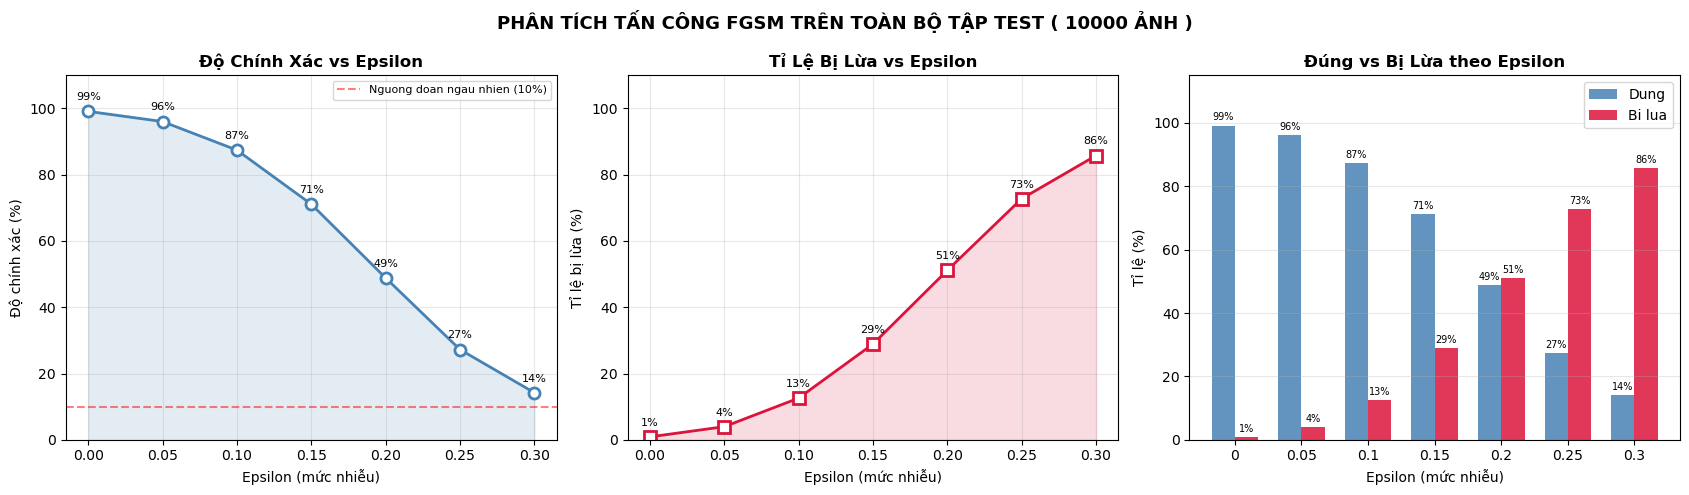

In [13]:
# BIỂU ĐỒ SO SÁNH TOÀN DIỆN
fool_rates = [1 - a for a in accuracies]   # Tỉ lệ bị lừa = 1 - accuracy

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('PHÂN TÍCH TẤN CÔNG FGSM TRÊN TOÀN BỘ TẬP TEST ( 10000 ẢNH )',
             fontsize=13, fontweight='bold')

# Biểu đồ 1: Accuracy vs Epsilon
ax1 = axes[0]
ax1.plot(epsilons, [a * 100 for a in accuracies], 'o-', color='steelblue',
         linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(epsilons, [a * 100 for a in accuracies], alpha=0.15, color='steelblue')
for x, y in zip(epsilons, accuracies):
    ax1.annotate(f'{y*100:.0f}%', (x, y*100), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)
ax1.set_title('Độ Chính Xác vs Epsilon', fontweight='bold')
ax1.set_xlabel('Epsilon (mức nhiễu)')
ax1.set_ylabel('Độ chính xác (%)')
ax1.set_ylim(0, 110)
ax1.set_xticks(epsilons)
ax1.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Nguong doan ngau nhien (10%)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Biểu đồ 2: Tỉ lệ bị lừa vs Epsilon
ax2 = axes[1]
ax2.plot(epsilons, [f * 100 for f in fool_rates], 's-', color='crimson',
         linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax2.fill_between(epsilons, [f * 100 for f in fool_rates], alpha=0.15, color='crimson')
for x, y in zip(epsilons, fool_rates):
    ax2.annotate(f'{y*100:.0f}%', (x, y*100), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)
ax2.set_title('Tỉ Lệ Bị Lừa vs Epsilon', fontweight='bold')
ax2.set_xlabel('Epsilon (mức nhiễu)')
ax2.set_ylabel('Tỉ lệ bị lừa (%)')
ax2.set_ylim(0, 110)
ax2.set_xticks(epsilons)
ax2.grid(True, alpha=0.3)

# biểu đồ 3: So sánh Đúng vs Sai
ax3 = axes[2]
bar_w = 0.35
x_pos = np.arange(len(epsilons))
bars1 = ax3.bar(x_pos - bar_w/2, [a * 100 for a in accuracies],
                bar_w, label='Dung', color='steelblue', alpha=0.85)
bars2 = ax3.bar(x_pos + bar_w/2, [f * 100 for f in fool_rates],
                bar_w, label='Bi lua', color='crimson', alpha=0.85)
ax3.set_title('Đúng vs Bị Lừa theo Epsilon', fontweight='bold')
ax3.set_xlabel('Epsilon (mức nhiễu)')
ax3.set_ylabel('Tỉ lệ (%)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([str(e) for e in epsilons])
ax3.set_ylim(0, 115)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
    # Ghi số lên đỉnh mỗi cột
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()


---
## Tổng Kết


> Mô hình đạt **99.1% độ chính xác** khi không bị tấn công — gần như hoàn hảo trên dữ liệu sạch.
>
> Tuy nhiên, chỉ cần thêm nhiễu FGSM với `ε = 0.3` (thay đổi tối đa **77/255 ≈ 30% giá trị mỗi pixel**, mắt người hoàn toàn không nhận ra), độ chính xác **sụp đổ xuống 14.2%** — gần bằng mức đoán mù ngẫu nhiên (10% với 10 lớp).
>
> Nói cách khác: **mô hình gần như đoán mù hoàn toàn sau khi bị tấn công FGSM**, dù ảnh nhìn bằng mắt vẫn rõ ràng như cũ. Điều này chứng minh mạng nơ-ron **cực kỳ nhạy cảm** với nhiễu có chủ đích — một lỗ hổng bảo mật nghiêm trọng cần được quan tâm trong các ứng dụng thực tế.



### Check ảnh test


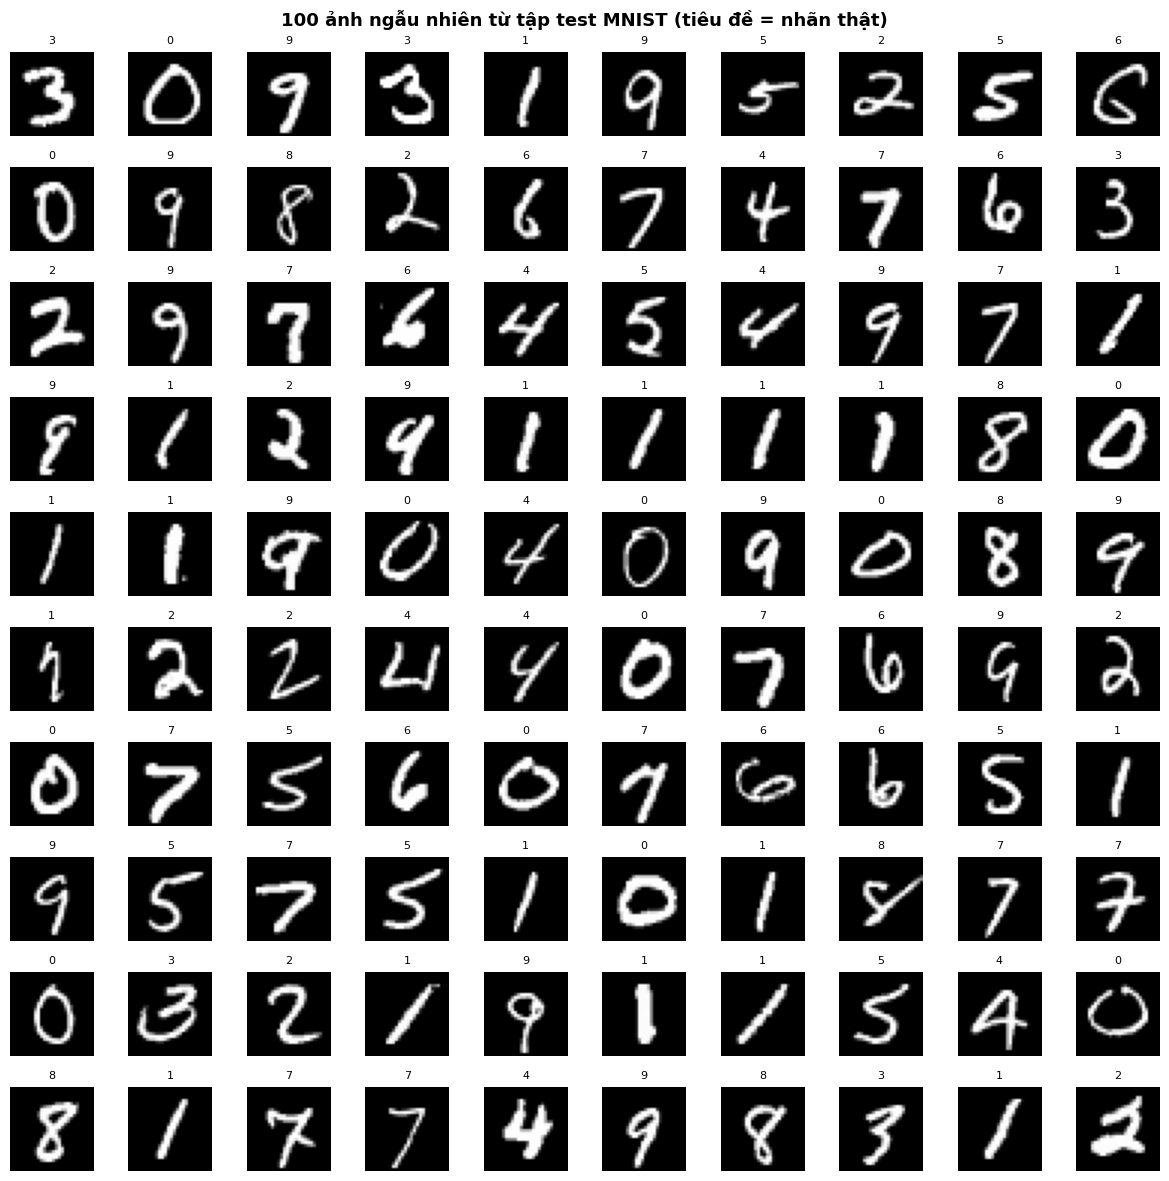

In [15]:
from torchvision import datasets, transforms

mnist_test = datasets.MNIST('dataset', train=False, download=True,
                             transform=transforms.ToTensor())

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
axes = axes.flatten()

import random
indices = random.sample(range(len(mnist_test)), 100)  # lấy 100 ảnh ngẫu nhiên

for i, idx in enumerate(indices):
    img, label = mnist_test[idx]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(str(label), fontsize=8)
    axes[i].axis('off')

plt.suptitle('100 ảnh ngẫu nhiên từ tập test MNIST (tiêu đề = nhãn thật)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Bên trong file trọng số .pth

In [16]:
# Tải state_dict từ file
pretrained_model = "models/lenet_mnist_model.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"
state_dict = torch.load(pretrained_model, map_location=device, weights_only=True)

# In ra tất cả các key trong state_dict
print("Các tham số được lưu trong file 'lenet_mnist_model.pth':")
for key in state_dict.keys():
    print(f"- {key}")

Các tham số được lưu trong file 'lenet_mnist_model.pth':
- conv1.weight
- conv1.bias
- conv2.weight
- conv2.bias
- fc1.weight
- fc1.bias
- fc2.weight
- fc2.bias
